In [1]:
import matplotlib.pyplot as plt
import torch #파이토치 메인 라이브러리
import torch.nn as nn
import torch.optim as optim # 최적화 알고리즘
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler # 피처값 0과 1 사이로 압축

In [2]:
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
df=pd.read_csv('./data/boston_house.csv')
feature=df.drop('MEDV', axis=1)
# MEDV 열만 뽑아내서 target에 저장
target=df.pop('MEDV')

In [4]:
X=feature.values
y=target.values

In [5]:
# 학습.테스트용(20%) 분리
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=1)

In [6]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 14) (102, 14) (404,) (102,)


In [7]:
print(feature.isna().sum())

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
B             0
LSTAT         0
dtype: int64


In [8]:
print(target.isna().sum())

0


In [9]:
sc=MinMaxScaler() # [0,1] 사이로 압축 (최소값 0, 최대값 1)
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [10]:
# 넘파이 -> 텐서 객체로 변환해야한다!!!!!!
# FloatTensor(넘파이)
X_train_tensor=torch.FloatTensor(X_train) # float 32
X_test_tensor=torch.FloatTensor(X_test)
y_train_tensor=torch.FloatTensor(y_train).view(-1,1)
y_test_tensor=torch.FloatTensor(y_test).view(-1,1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)
print(X_test_tensor.shape)
print(y_test_tensor.shape)
# [데이터 개수, 출력개수]

# 데이터 모델 통과시, 입력과 출력의 차원이 맞지않으면 오류 발생

torch.Size([404, 14])
torch.Size([404, 1])
torch.Size([102, 14])
torch.Size([102, 1])


In [11]:
#파이토치에서 모델 만들때 반드시 nn.Module 상속받아야 한다
#심층 신경망(deep neural network)
#input (14)
#layer1(64) -> relu함수 적용
#layer2(32) -> relu함수 적용
#output(1) 
class LinearReg(nn.Module):
    def __init__(self, input_size, ouptut_size):
        super().__init__()
        self.fc1=nn.Linear(input_size,64) # 14개 입력받아서 64개의 노드로 확장
        self.fc2=nn.Linear(64, 32) # 64개 -> 32개로 줄임
        self.fc3=nn.Linear(32, output_size) # 32개 최종적으로 1개의 값(집값) 내보내는 출력층

    def forward(self, x):
        x=torch.relu(self.fc1(x))
        x=torch.relu(self.fc2(x))
        ouptut=self.fc3(x)
        return ouptut

In [12]:
model=nn.Linear(X_train.shape[1], 1)
model

Linear(in_features=14, out_features=1, bias=True)

In [13]:
loss1=nn.MSELoss()
#lr: 한 번 업데이트 할때마다 파라미터(w,b) 얼마나 크게 조정할지 결정함
optimizer=optim.SGD(model.parameters(), lr=0.001)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [14]:
from torch.utils.data import TensorDataset, DataLoader

In [15]:
# 입력텐서와 레이블 텐서를 묶어서 하나의 데이터셋 객체로 만드려고
train_dataset=TensorDataset(X_train_tensor, y_train_tensor)
# print(train_dataset[0]) # X_train_tensor[0], y_train_tensor[0]

# 한번에 32개씩 학습 -> 매 epoch마다 순서를 섞어서 학습시킨다
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)

In [16]:
epoch_num=1000
loss_num=[]

for epoch in range(epoch_num):
    for x,y in train_loader:
        yhat=model(x) # __call__ -> forward 를 통해 예측값 계산
        loss=loss1(yhat,y) 
        # epoch_loss+=loss.item()*x.siae()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
       
    print("epoch: {0}, loss:{1}".format(epoch+1, loss.item()))
    loss_num.append(loss.item())

epoch: 1, loss:476.15380859375
epoch: 2, loss:657.9247436523438
epoch: 3, loss:485.26983642578125
epoch: 4, loss:428.4523010253906
epoch: 5, loss:265.25653076171875
epoch: 6, loss:303.9534912109375
epoch: 7, loss:200.37445068359375
epoch: 8, loss:148.5775604248047
epoch: 9, loss:255.64877319335938
epoch: 10, loss:170.9439697265625
epoch: 11, loss:133.93240356445312
epoch: 12, loss:238.69229125976562
epoch: 13, loss:93.08253479003906
epoch: 14, loss:101.184326171875
epoch: 15, loss:75.90299987792969
epoch: 16, loss:55.4881477355957
epoch: 17, loss:159.33714294433594
epoch: 18, loss:99.8171615600586
epoch: 19, loss:86.93891906738281
epoch: 20, loss:70.89300537109375
epoch: 21, loss:119.54742431640625
epoch: 22, loss:79.5604476928711
epoch: 23, loss:85.40897369384766
epoch: 24, loss:54.32575607299805
epoch: 25, loss:69.89476013183594
epoch: 26, loss:99.28936767578125
epoch: 27, loss:188.85202026367188
epoch: 28, loss:100.47151947021484
epoch: 29, loss:57.148956298828125
epoch: 30, loss:60

In [17]:
print(loss1(model(X_test_tensor),y_test_tensor))

tensor(35.6014, grad_fn=<MseLossBackward0>)


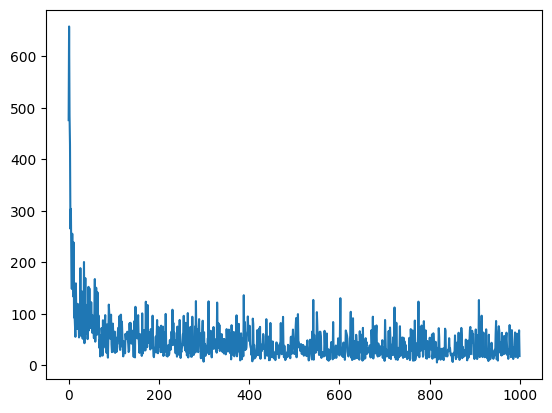

In [18]:
plt.plot(loss_num)

In [19]:
y_pred=model(X_test_tensor).detach().numpy()

In [20]:
# r2_score, mse
from sklearn.metrics import mean_squared_error, r2_score

print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

35.60143331842835
0.6397614718860494


Text(0.5, 1.0, 'Boston House Price Prediction')

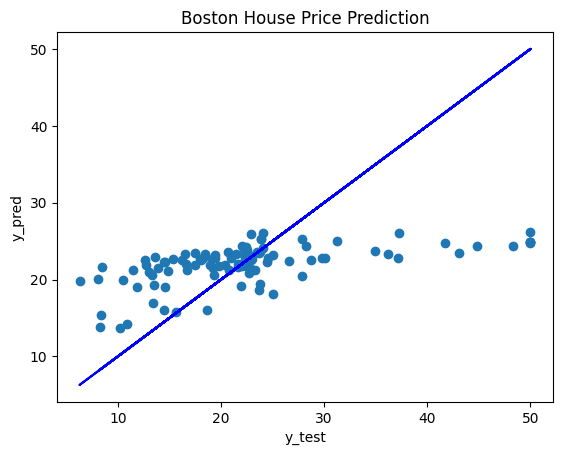

In [42]:
# y_test, y_pred 시각화
# plot => y_test
plt.scatter(y_test, y_pred)
plt.plot(y_test,y_test,'b')
plt.xlabel('y_test')
plt.ylabel('y_pred')
plt.title('Boston House Price Prediction')